# Delivery Lead-time Regression · Phase 2

## tl;dr
Predict fractional purchase-to-receipt days at order placement. On the same 7,003 March validation
orders, MAE is 9.83 days for the quote, 6.92 for plain linear, 6.91 for Ridge, 7.20 for a single tree,
and 7.01 for the forest. Ridge reduces early-fold instability; the forest improves the tree baseline
but does not beat the linear models in March. All learned models still underestimate duration by
about 4.3 days and have about 53-day MAE on 37 deliveries above 60 days.
These are **development results**, not final-test results. Four pipelines and 39,445 aligned temporal
OOF rows are prepared from legacy geography. The later test remains unscored.


**Data audit update (2026-10-05):** the cohort/target and non-geographic inputs pass independent source checks. Legacy mean postal coordinates contain localized errors. The model results and OOF below still use that legacy preparation; a screened postal-median input preview is available in `data_preparation_audit.ipynb`. Formal preparation now defaults to repaired geography and v2 inputs are verified in `versions/preparation_v2/`. Regenerate fits/predictions/OOF together before renewed handoff; outputs below still belong to v1. No models were fitted during the audit.

**Model review update (2026-10-05):** [baseline_variant_review.ipynb](baseline_variant_review.ipynb) separately executes 18 configurations on v2 and the same folds/March orders. CV-selected Ridge and recency forest score 6.847 and 6.913 March MAE. Gains are small and systematic underprediction remains. The outputs below retain historical v1 fits; the isolated review does not replace the canonical handoff. See [Chinese review](../docs/baseline_variant_review.md).

**Feature/maturity update (2026-10-05):** [feature_optimization.ipynb](feature_optimization.ipynb) executes a further bounded feature search and mature historical scoring. Added features are not selected; Ridge/forest remain 6.847/6.913 March MAE. Mature historical CV is 5.236/5.219, restoring 3,669 slow orders; historical conditional scores below must retain that label. See [Chinese explanation](../docs/feature_optimization.md). Fitting/March/test boundaries remain unchanged.

## Context & Methods
**Target:** `(receipt_timestamp - purchase_timestamp).total_seconds() / 86400`.
**Grain:** one order. **Prediction point:** purchase. **Stakeholder:** customer-service/order-operations
manager using a duration estimate to support arrival-expectation communication.

### Problem Scoping Checklist
1. Derivable target: supplied order timestamps; no external target data.
2. Realistic features: explicit purchase-time allowlist; outcome, review, payment and ID roles excluded.
3. Signal: Phase 1 found distance, promise and freight associations; prediction value is evaluated below.
4. Tail handling: retain valid >60-day orders; MAE, RMSE, tail error and a training-CV log-target trial.
5. Stakeholder: customer-service/order operations; this point estimate is not a calibrated promise interval.

### Key Assumptions
Only completed deliveries have observable targets; itemless orders are excluded consistently with Phase 1.
The archived promise is assumed to be the original quote. Catalogue attributes, basket contents, seller selection,
charges and destination are assumed to represent purchase-time snapshots; their revision histories are absent.
Postal locations are static reference proxies; the data-audit companion verifies repaired v2 geography; model refitting remains pending. Source timestamps have no timezone; no conversion is applied.
Orders whose labels are unavailable at a forecast cutoff cannot enter that training set.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
from delivery_regression import (prepare_data, train_and_validate, explain, plot_results, FEATURES)
pd.set_option('display.max_columns', 12)


## Data
### 1. Build and audit order-level inputs
Read the seven course tables needed for this task. Payments and reviews are not joined.
Dimension joins are checked for many-to-one integrity. Order totals, all-seller routes and target
definitions follow Phase 1; audited geographic preparation now screens out-of-envelope coordinates
and uses unique-coordinate postal medians (v2). The retained model outputs below were executed with
legacy postal means (v1), so they need refitting before v2 performance is reported.
Provide `OLIST_CSV_DIR` or `OLIST_ARCHIVE` outside this course workspace.


Independent source audit: 99,441 source orders → 96,478 delivered → 96,470 with receipt. No delivered order is lost by the item requirement. All targets and non-geographic inputs match independent reconstruction. Geography requires repair: 29 out-of-envelope rows distort old postal means. See the executed companion `data_preparation_audit.ipynb`; the original outputs below remain legacy-version evidence. Event chronology contradictions in 84 orders are separately flagged, not used as inputs or automatically excluded.

In [2]:
eligible, split_summary, quality = prepare_data()
display(pd.Series(quality, name='value').to_frame())
display(pd.read_csv(ROOT / 'outputs/tables/source_inventory.csv')[['table', 'rows']])


,value
source_orders,99441
item_rows,112650
orders_with_items,98666
orders_without_items,775
eligible_orders,96470
delivered_with_missing_target,8
retained_over_60_days,306
missing_max_distance,476
mean_target_days,12.558217
median_target_days,10.217477


,table,rows
0,orders,99441
1,items,112650
2,customers,99441
3,sellers,3095
4,products,32951
5,geo,1000163
6,translation,71


### 2. Freeze the chronological experiment
Training labels must be observed before **2018-03-01**. March purchases form validation, with labels
observable before **2018-07-01**. April-June is a maturation gap. Purchases from July onward form the locked
final test. These dates were fixed from timestamp coverage before model scores were inspected.
Delayed labels are explicitly counted, not imputed or truncated. This completed-label selection can
underrepresent slow recent orders; it is a limitation, not evidence that these orders do not exist.

Training CV predicts Jul–Sep 2017, Oct–Dec 2017 and Jan–Feb 2018 using only earlier purchases already
delivered at each start. Every fold fits its own imputation, encoding and scaling. IDs are audit keys,
not inputs. Calendar categories have fixed known domains (12 months, 7 weekdays, 24 hours); only state/route/product
rare groups are learned within each fold. Unseen levels are counted in a saved audit table.
Operational predictions are bounded below at zero via `predict_days`.


In [3]:
display(split_summary)
display(pd.DataFrame({'predictor': FEATURES}))


,split,n,first_purchase,last_purchase,tail_over_60
0,maturation_gap,19643,2018-04-01 00:11:32,2018-06-30 23:59:49,34
1,pending_label_train_cutoff,3673,2017-11-14 21:07:55,2018-02-28 23:57:55,105
2,test_locked,12507,2018-07-01 00:25:07,2018-08-29 15:00:37,6
3,train,53644,2016-09-15 12:16:38,2018-02-27 09:53:16,124
4,validation,7003,2018-03-01 00:00:00,2018-03-31 23:54:10,37


,predictor
0,promised_lead_time_days
1,max_distance_km
2,total_price
3,total_freight
4,freight_ratio
5,item_count
6,seller_count
7,avg_product_weight_g
8,any_distance_missing
9,any_weight_missing


## Results
### 3–4. Fit baselines and compare the random-forest variant
References: quote, training mean and training median. Learned baselines: plain linear regression and
a single decision tree (two fixed depth settings). After unstable early-fold linear coefficients were
identified, Ridge alpha=10/100 was added as a limited regularization check within the linear family.
Forest search: two raw-target settings plus
one controlled `log1p` target trial. Hyperparameters are selected only by mean training-CV MAE.
All validation metrics use the same March orders. CV is used for tuning; March validation is the
separate model comparison. MAE is interpretable in days; RMSE emphasizes large errors; R² and bias
provide complementary context. Small tail slices are descriptive and uncertain.


For the new bounded v2 review of regularisation, log inputs, forest complexity, recency weighting and matched boosting losses, see [baseline_variant_review.ipynb](baseline_variant_review.ipynb). Its results are isolated from this retained first-run experiment.

In [4]:
comparison, cv, models, validation_predictions, oof = train_and_validate(eligible)
display(pd.read_csv(ROOT / 'outputs/tables/cv_summary.csv').round(3))
display(comparison.round(3))
display(pd.read_csv(ROOT / 'outputs/tables/fold_summary.csv'))


CV 1/3 linear: MAE=17.663


CV 1/3 ridge_a10: MAE=4.341


CV 1/3 ridge_a100: MAE=3.933


CV 1/3 tree_d8: MAE=4.158


CV 1/3 tree_d14: MAE=4.309


...

Validation tree: MAE=7.199


Validation forest: MAE=7.007


,family,algorithm,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean
0,linear,linear,linear,9.580,7.091,14.339
1,linear,ridge,ridge_a10,4.911,0.995,7.353
2,linear,ridge,ridge_a100,4.616,0.961,7.025
3,tree-based,forest,rf_d16_l5,4.554,0.851,6.982
4,tree-based,forest,rf_d24_l10,4.548,0.848,6.969
5,tree-based,forest,rf_log_d24_l10,4.606,0.944,7.242
6,tree-based,tree,tree_d14,4.851,0.768,7.305
7,tree-based,tree,tree_d8,4.695,0.777,7.133


,model,role,period,n,MAE_days,RMSE_days,R2,bias_days,P90_abs_error_days,tail_n,tail_MAE_days
0,promise,reference,March 2018 validation,7003,9.825,12.202,-0.135,5.732,18.840,37,40.754
1,train_mean,reference,March 2018 validation,7003,8.407,11.943,-0.087,-3.384,19.268,37,56.479
2,train_median,reference,March 2018 validation,7003,8.645,12.594,-0.209,-5.238,21.122,37,58.334
3,linear,baseline,March 2018 validation,7003,6.918,10.675,0.131,-4.329,17.089,37,52.950
4,ridge,regularized_variant,March 2018 validation,7003,6.914,10.664,0.133,-4.313,17.041,37,52.923
5,tree,baseline,March 2018 validation,7003,7.199,11.108,0.059,-4.283,18.109,37,53.028
6,forest,variant_1,March 2018 validation,7003,7.007,10.829,0.106,-4.367,17.648,37,52.552


,fold,forecast_cutoff,end,train_n,validation_n,latest_training_receipt
0,1,2017-07-01 00:00:00,2017-10-01 00:00:00,13106,12215,2017-06-30 19:09:42
1,2,2017-10-01 00:00:00,2018-01-01 00:00:00,24828,17260,2017-09-30 20:09:53
2,3,2018-01-01 00:00:00,2018-03-01 00:00:00,41197,9970,2017-12-31 15:19:16


### 5. Error and feature analysis
Permutation importance measures reliance of the forest on a feature in 2,000 fixed validation rows;
three repeats show permutation variability, not confidence intervals. Correlated inputs can share
importance. Outcome-duration groups are diagnostics, never prediction features.


In [5]:
importance = explain(models, eligible, validation_predictions)
plot_results(comparison, cv, validation_predictions, importance)
display(importance.round(3))
display(pd.read_csv(ROOT / 'outputs/tables/route_errors.csv').round(3))


,feature,MAE_increase_days,repeat_std_days
1,max_distance_km,0.555,0.024
0,promised_lead_time_days,0.421,0.030
11,route_group,0.358,0.028
10,customer_state,0.302,0.023
12,category_group,0.044,0.010
3,total_freight,0.028,0.002
14,purchase_weekday,0.026,0.009
7,avg_product_weight_g,0.020,0.009
6,seller_count,0.005,0.001
4,freight_ratio,0.004,0.003


,model,slice,n,MAE_days,RMSE_days,R2,bias_days,P90_abs_error_days,tail_n,tail_MAE_days
0,promise,All sellers same-state,2573,7.967,9.917,-1.163,6.673,13.304,2,35.938
1,promise,Any seller cross-state,4430,10.904,13.351,-0.323,5.185,20.165,35,41.029
2,train_median,All sellers same-state,2573,5.534,6.995,-0.076,1.862,8.994,2,54.399
3,train_median,Any seller cross-state,4430,10.452,14.911,-0.651,-9.362,25.087,35,58.558
4,linear,All sellers same-state,2573,4.124,6.460,0.082,-1.541,9.203,2,52.534
5,linear,Any seller cross-state,4430,8.541,12.486,-0.157,-5.948,20.835,35,52.974
6,ridge,All sellers same-state,2573,4.108,6.439,0.088,-1.518,9.118,2,52.752
7,ridge,Any seller cross-state,4430,8.543,12.478,-0.156,-5.937,20.759,35,52.933
8,tree,All sellers same-state,2573,4.052,6.448,0.085,-1.912,9.508,2,56.135
9,tree,Any seller cross-state,4430,9.027,13.074,-0.269,-5.661,22.115,35,52.851


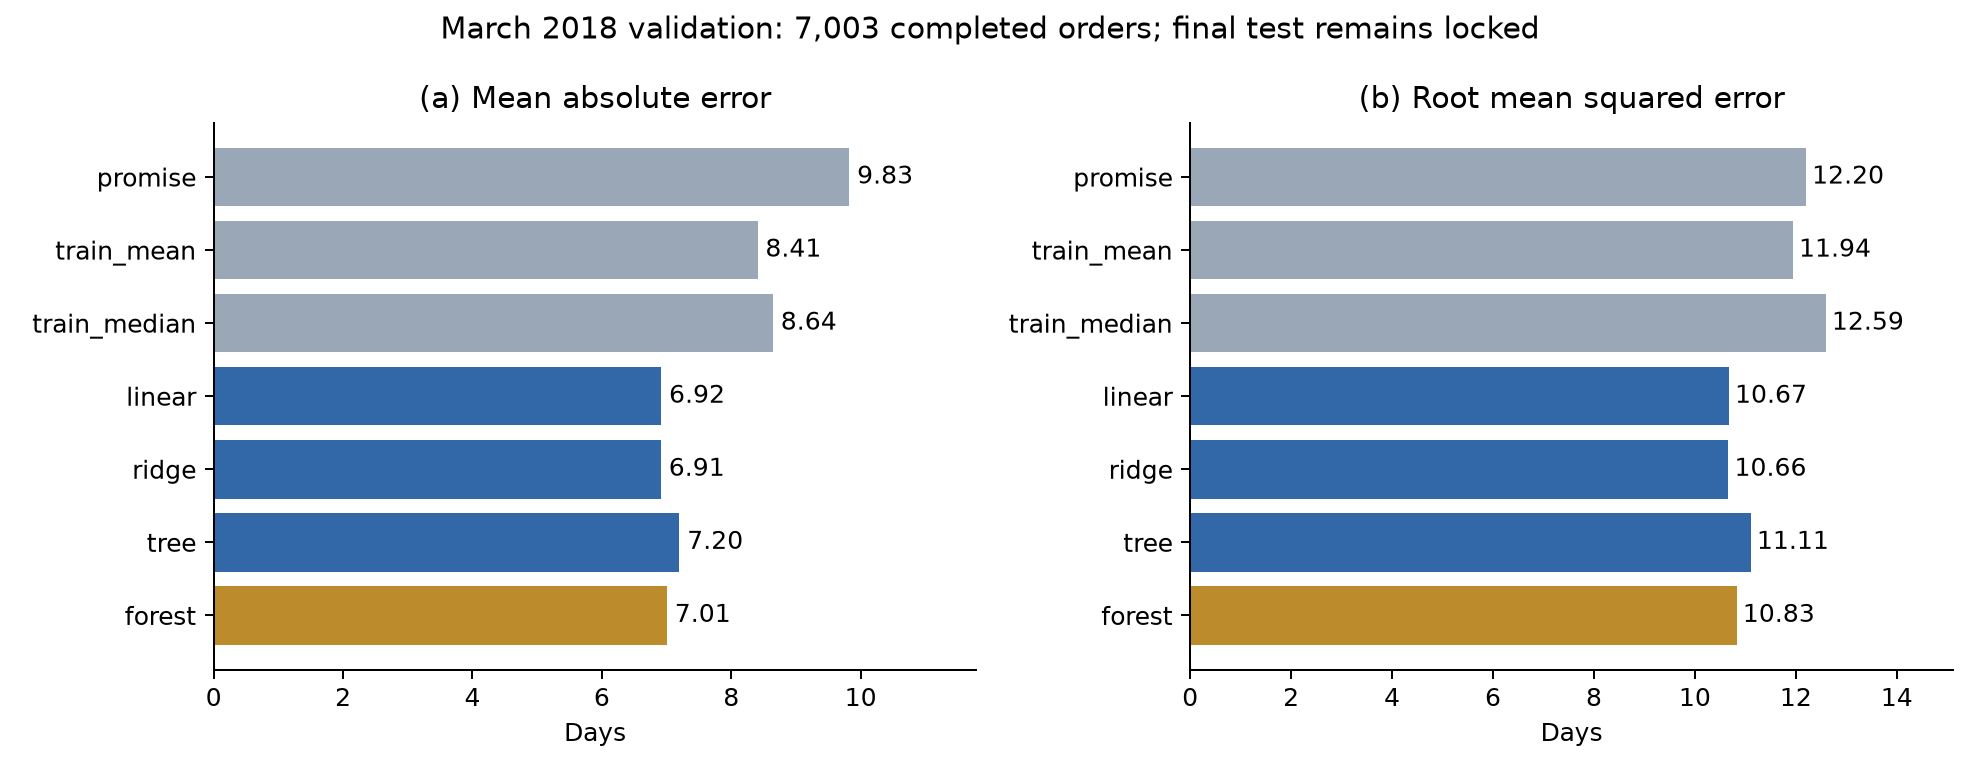

In [6]:
display(Image(filename=str(ROOT / 'outputs/figures/01_model_comparison.png')))

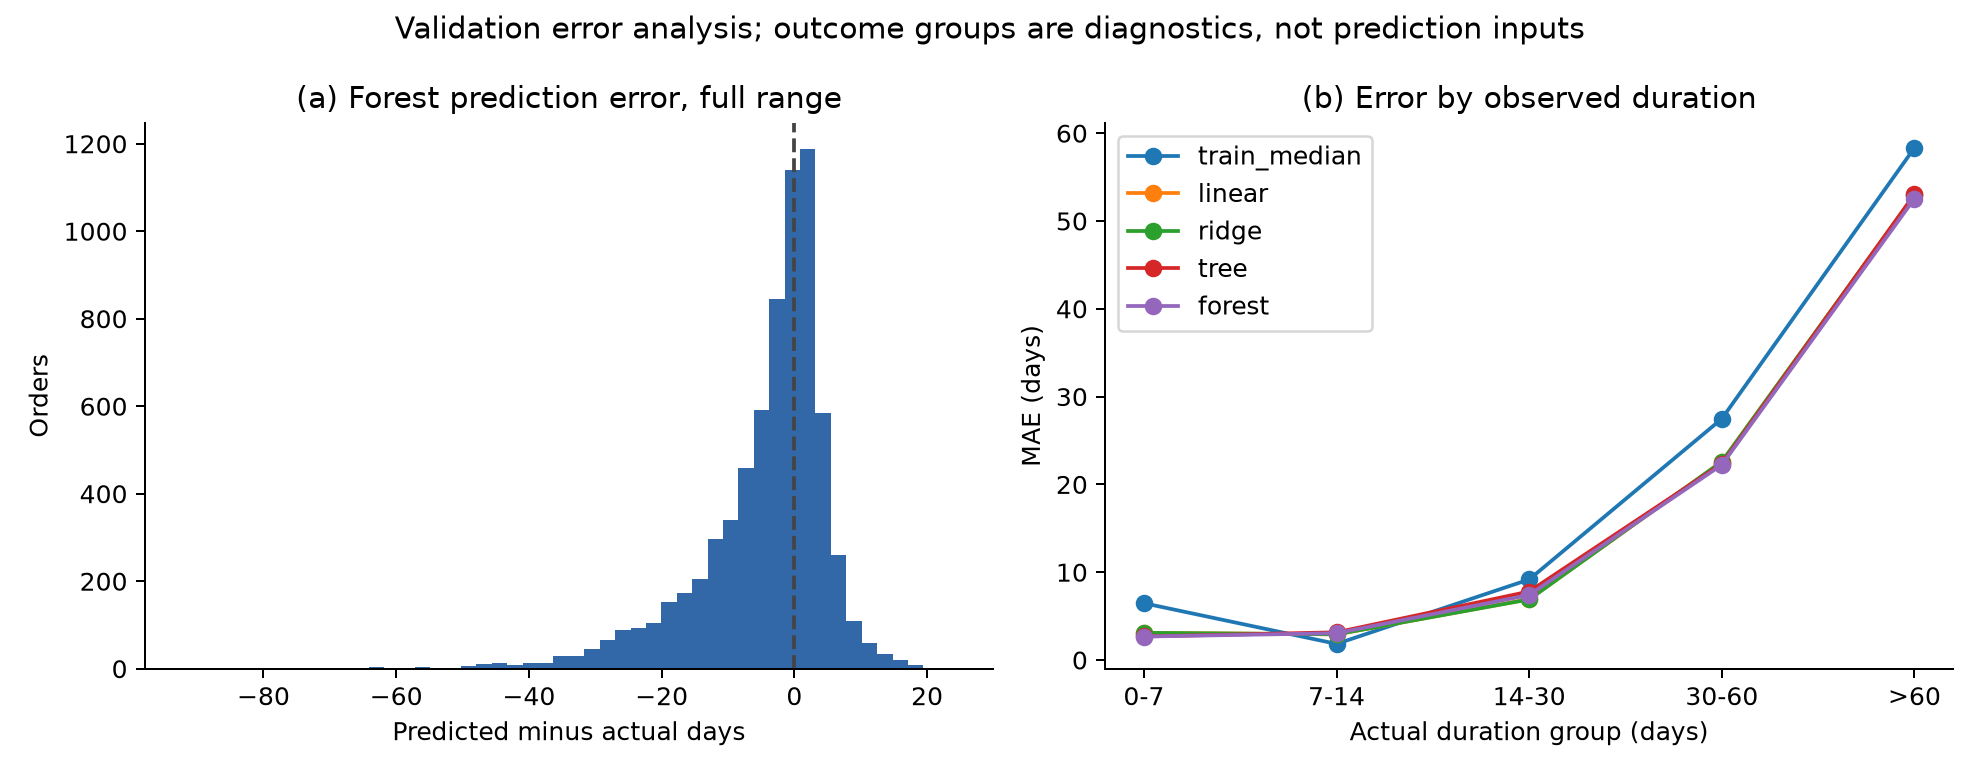

In [7]:
display(Image(filename=str(ROOT / 'outputs/figures/02_error_analysis.png')))

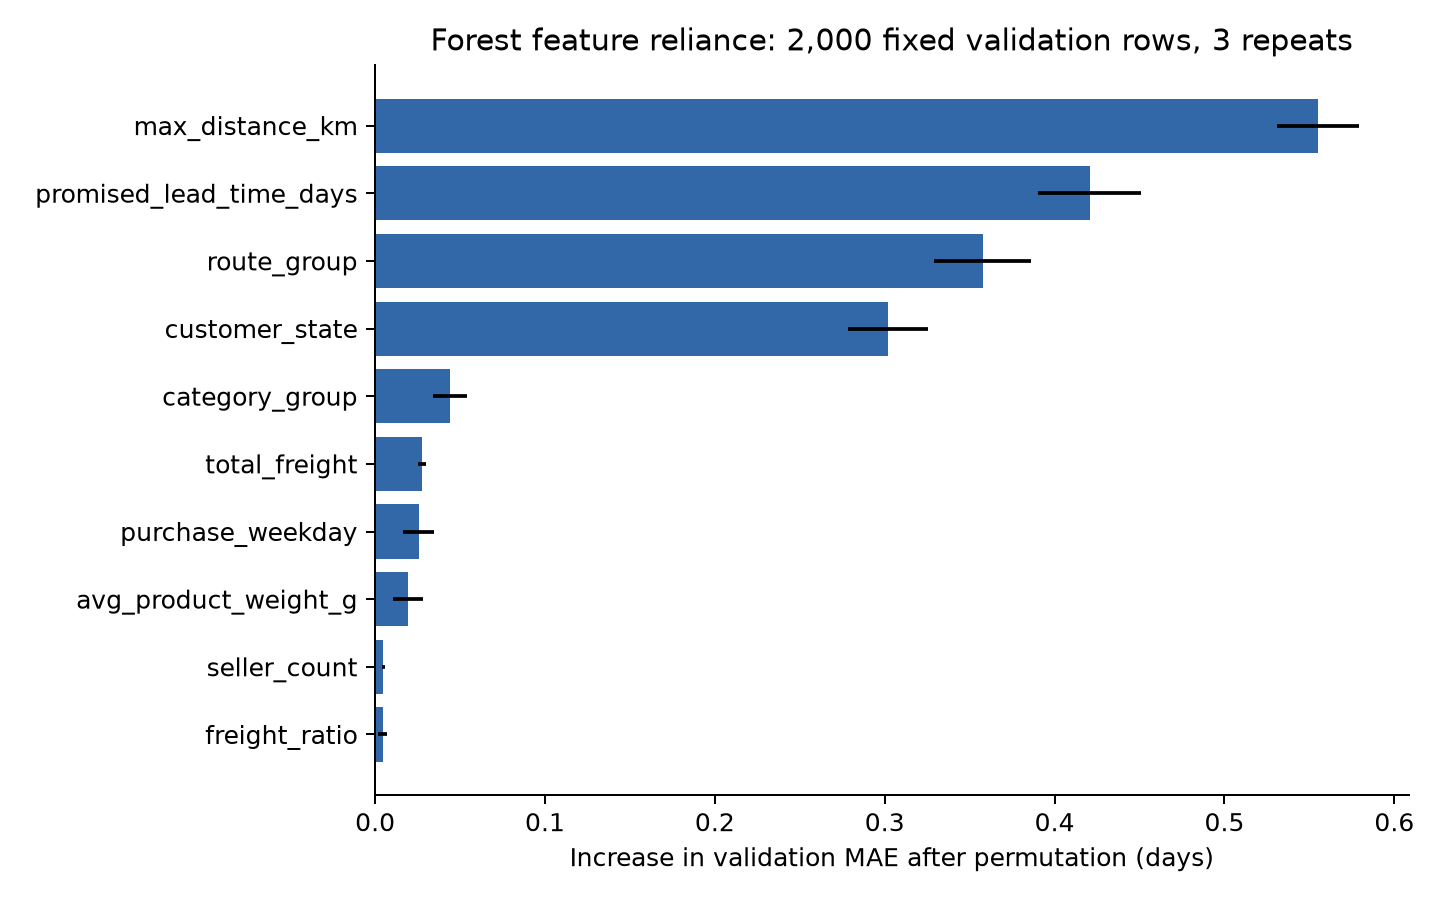

In [8]:
display(Image(filename=str(ROOT / 'outputs/figures/03_feature_importance.png')))

### 6. Stacking handoff
Local OOF file: `outputs/oof/base_oof_predictions.csv`. Each selected model's predictions come from
a fold that excludes the row and trains only on labels known at its forecast cutoff. Initial warmup
orders have no earlier-trained forecast and are excluded from meta-training. Configurations were
fixed for each candidate comparison, with Ridge added during development; selection by training CV
is not nested and does not make OOF error an unbiased final estimate.
The separate March validation remains available for meta-model selection. Do not use base predictions
on their own fitting rows, validation labels or test labels as meta-training inputs.

Fitted development pipelines, exact feature schema, fold manifest and run instructions accompany OOF.
Stacking and final-test scoring are not performed here. After designs are frozen, refit permitted
pre-July historical completed orders and evaluate all models on the same locked test orders.


In [9]:
display(pd.Series({'OOF_rows': len(oof), 'training_rows': int(eligible.split.eq('train').sum()),
                  'final_test_scored': False, 'stacking_fitted': False}).to_frame('status'))
assert oof.order_id.is_unique
assert oof[['linear_oof_days','ridge_oof_days','tree_oof_days','forest_oof_days']].notna().all().all()
assert not set(oof.order_id) & set(eligible.loc[eligible.split.eq('validation'), 'order_id'])


,status
OOF_rows,39445
training_rows,53644
final_test_scored,False
stacking_fitted,False


## Takeaways
The candidate models improve March overall error relative to the quote and training constants,
while remaining poor at extreme delays. Ridge has the lowest March MAE (6.914 days), but its 0.004-day
advantage over plain linear is not evidence of meaningful superiority. Its temporal CV stability
improves substantially (mean MAE 4.616, fold SD 0.961, versus 9.580 and 7.091 for plain linear).
Forest CV MAE is 4.548; its log-target trial scores 4.606 and is not selected. CV cohorts have different
periods and maturity selection from March; their values cannot be pooled into a single ranking.

Observed mean duration shifts from 12.92 training days to 16.30 March days. This is consistent with a
harder later period but does not identify an operational cause. Distance, quote, route and state
are the strongest forest dependencies; permutation importance is predictive, not causal.
Ridge and forest remain candidates for stacking/final comparison, not deployment-selected models.
Valid long deliveries remain retained; the quote is closer than learned models on the small >60-day
slice despite poorer overall MAE. Remaining constraints include completed-delivery selection,
label maturity, archived-quote assumptions, static product/geography proxies and unobserved disruptions.
After stacking design freeze, refit permitted pre-test data and evaluate the same locked holdout.
See `docs/report_section.md`, `docs/validation_review.md` and `docs/stacking_handoff.md` for evidence and handoff.

## Sources and AI use
Course Olist ZIP; shared Phase 1 Notebook 00 (cells 38–45) and delivery Notebook 03 target definitions;
Phase 1 report p8/Figure 6 p14; teacher feedback. Full formulas and literature mapping are in `docs/`.
AI assisted implementation, explanation and debugging. Source checks, executed results and limitations
are recorded; report responsibility remains with the project team.
